
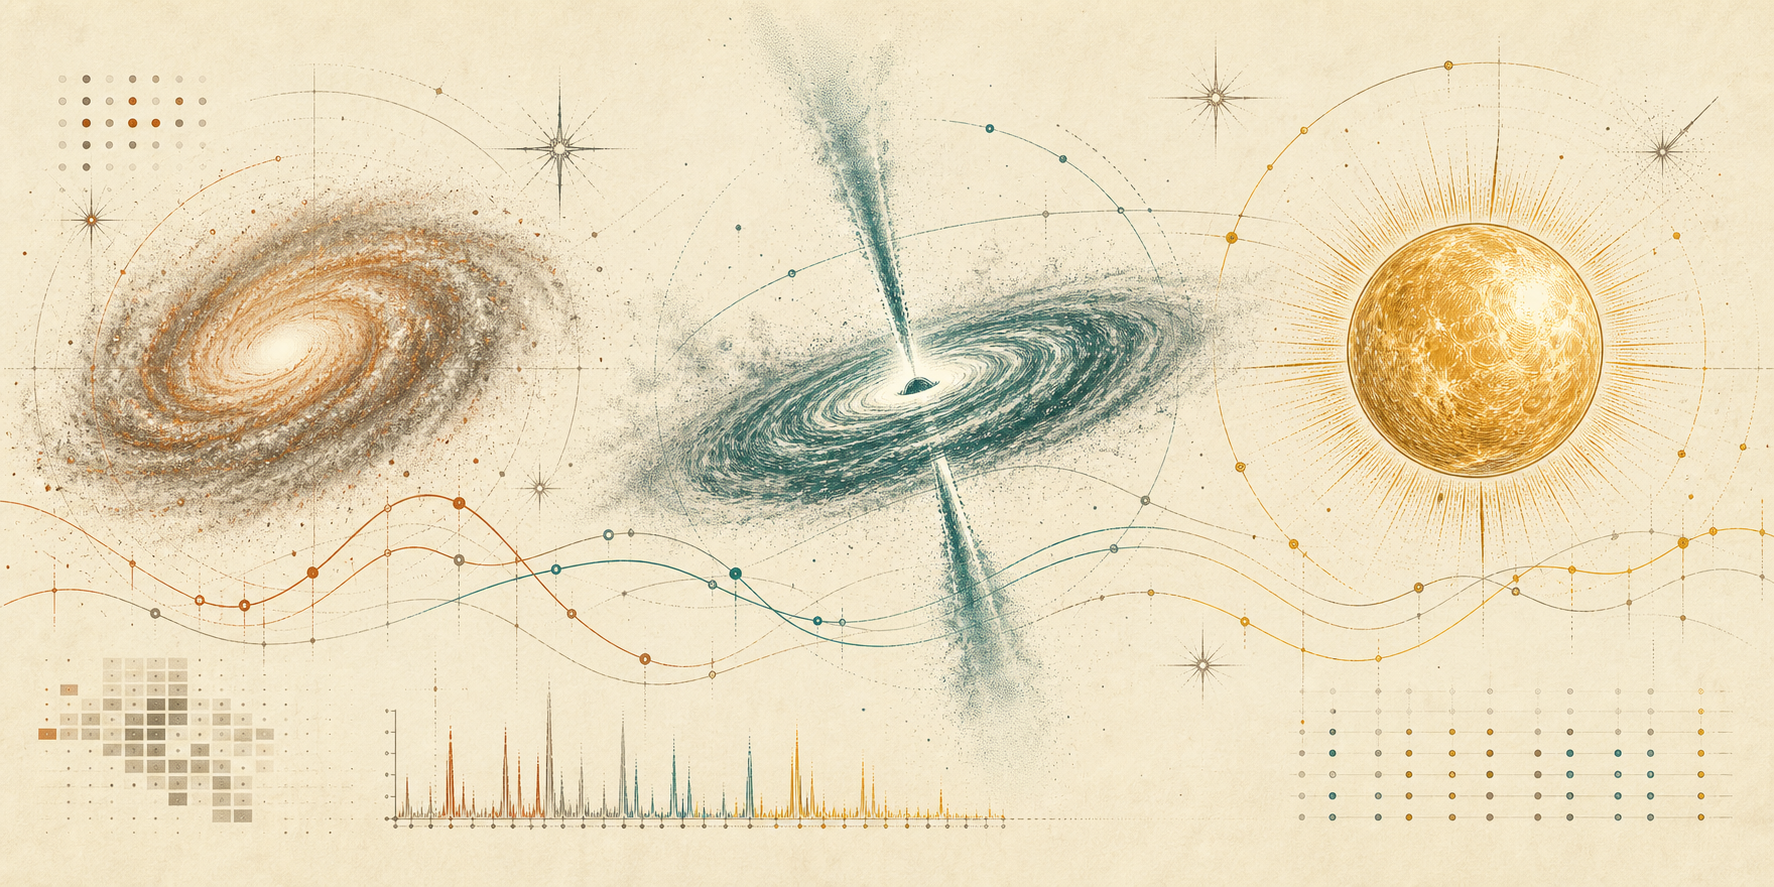

In [1]:
from pathlib import Path
import base64
from IPython.display import HTML, display

artifact_roots = [
    Path("/kaggle/input/datasets/analyticaobscura/stellar-class"),
    Path("/kaggle/input/stellar-class"),
    Path("/kaggle/input/s6e6-pairwise-residual-oof-artifacts"),
    Path("dataset"),
    Path.cwd() / "dataset",
]
if Path("/kaggle/input").exists():
    artifact_roots.extend(
        path.parent
        for path in sorted(Path("/kaggle/input").rglob("experiment_report.json"))
    )

ARTIFACT_DATA_DIR = next(
    (
        path for path in artifact_roots
        if (path / "experiment_report.json").exists()
        and (path / "stellar_classification_hero.png").exists()
    ),
    None,
)
hero_path = (
    ARTIFACT_DATA_DIR / "stellar_classification_hero.png"
    if ARTIFACT_DATA_DIR is not None
    else None
)
if hero_path is None:
    raise FileNotFoundError(
        "The stellar-class artifact dataset or its hero image was not found."
    )

hero_b64 = base64.b64encode(hero_path.read_bytes()).decode("ascii")
display(HTML(
    f'''<div style="border-radius:16px;overflow:hidden;border:1px solid #CFC4AF;
    box-shadow:0 12px 28px rgba(74,63,48,.18);margin-bottom:16px;">
    <img src="data:image/png;base64,{hero_b64}"
         alt="Galaxy, quasar and star classification banner"
         style="width:100%;height:340px;object-fit:cover;object-position:center;display:block;">
    </div>'''
))

<div style="padding:34px 32px 36px 32px;text-align:center;border-radius:16px;
border:1px solid #CFC4AF;box-shadow:0 12px 28px rgba(74,63,48,.14);
background:#F4F1E8;">
  <div style="color:#168C8C; font-size:12px; letter-spacing:3px; font-weight:700;">
    PLAYGROUND SERIES S6E6 · STELLAR CLASSIFICATION
  </div>
  <h1 style="color:#202522; font-family:Georgia,serif; font-size:42px; margin:12px 0 8px 0;">
    Pairwise Residual Stacking
  </h1>
  <p style="color:#69706A; max-width:820px; margin:16px auto 0 auto; font-size:15px; line-height:1.75;">
    An OOF-based study of stellar classification, model-family diversity
    and cross-fitted residual learning.
  </p>
  <hr style="border:0; border-top:1px solid #C8BDA9; width:65%; margin:28px auto 22px auto;">
  <h3 style="color:#202522; margin:0; font-family:Georgia,serif;">Ozan M.</h3>
  <p style="color:#69706A; margin:7px 0 18px 0;">Data Scientist · ML Engineer · Kaggle Competitor</p>
  <div>
    <a href="https://www.linkedin.com/in/ozan-mohurcu" target="_blank"
       style="display:inline-block;background:#168C8C;color:white;padding:9px 18px;
       border-radius:22px;text-decoration:none;margin:4px;font-weight:700;">LinkedIn</a>
    <a href="https://github.com/Ozan-Mohurcu" target="_blank"
       style="display:inline-block;background:#202522;color:white;padding:9px 18px;
       border-radius:22px;text-decoration:none;margin:4px;font-weight:700;">GitHub</a>
    <a href="https://ozan-mohurcu.github.io/" target="_blank"
       style="display:inline-block;background:#B5653A;color:white;padding:9px 18px;
       border-radius:22px;text-decoration:none;margin:4px;font-weight:700;">Portfolio</a>
  </div>
</div>

<div style="background:#F4F1E8;border:1px solid #CFC4AF;border-radius:12px;
padding:22px 24px;margin-top:18px;box-shadow:0 6px 18px rgba(74,63,48,.10);">
  <div style="display:flex;justify-content:space-between;align-items:flex-end;
       border-bottom:1px solid #CFC4AF;padding-bottom:13px;margin-bottom:4px;">
    <div>
      <div style="color:#168C8C;font-size:11px;font-weight:700;letter-spacing:2px;">MODEL AUDIT</div>
      <div style="color:#202522;font-size:19px;font-weight:700;margin-top:4px;">Ensemble structure</div>
    </div>
    <div style="color:#B5653A;font-size:12px;font-weight:700;">OOF · CROSS-FITTED</div>
  </div>
  <div style="display:grid;grid-template-columns:repeat(4,1fr);">
    <div style="padding:20px 18px 12px 4px;border-right:1px solid #CFC4AF;">
      <div style="font-size:30px;font-weight:800;color:#202522;">23</div>
      <div style="color:#168C8C;font-size:12px;font-weight:700;letter-spacing:1px;">OOF SOURCES</div>
      <div style="color:#69706A;font-size:11px;margin-top:5px;">quality-filtered predictions</div>
    </div>
    <div style="padding:20px 18px 12px 22px;border-right:1px solid #CFC4AF;">
      <div style="font-size:30px;font-weight:800;color:#202522;">10</div>
      <div style="color:#168C8C;font-size:12px;font-weight:700;letter-spacing:1px;">MODEL FAMILIES</div>
      <div style="color:#69706A;font-size:11px;margin-top:5px;">family-balanced selection</div>
    </div>
    <div style="padding:20px 18px 12px 22px;border-right:1px solid #CFC4AF;">
      <div style="font-size:30px;font-weight:800;color:#202522;">5</div>
      <div style="color:#B5653A;font-size:12px;font-weight:700;letter-spacing:1px;">CV FOLDS</div>
      <div style="color:#69706A;font-size:11px;margin-top:5px;">out-of-fold evaluation</div>
    </div>
    <div style="padding:20px 4px 12px 22px;">
      <div style="font-size:30px;font-weight:800;color:#202522;">118</div>
      <div style="color:#B5653A;font-size:12px;font-weight:700;letter-spacing:1px;">META FEATURES</div>
      <div style="color:#69706A;font-size:11px;margin-top:5px;">raw, vote and probability blocks</div>
    </div>
  </div>
</div>

### Notebook scope

The notebook follows the full analysis from the competition data to the final
prediction file. The emphasis is on three areas:

- the astrophysical structure visible in the raw features;
- diversity and agreement across the OOF model pool;
- validation of a focused second-stage classifier.

Each stage is accompanied by diagnostics so that the modeling choices can be
read from the evidence rather than treated as a general recipe.

<div style="background:#F4F1E8; padding:24px 28px; border-radius:12px;
border:1px solid #D1C7B5; border-left:7px solid #B5653A; margin-top:28px;
box-shadow:0 6px 18px rgba(74,63,48,.10);">
  <div style="color:#168C8C; font-size:12px; font-weight:700; letter-spacing:2px;">SECTION 01</div>
  <h2 style="color:#202522; margin:5px 0 7px 0; font-family:Georgia,serif;">Setup</h2>
  <p style="color:#69706A; margin:0; line-height:1.65;">Imports, reproducibility settings and the shared plotting theme.</p>
</div>

In [2]:
from pathlib import Path
import hashlib
import json
import platform
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import balanced_accuracy_score, confusion_matrix, roc_auc_score

warnings.filterwarnings("ignore")

SEED = 260606
CLASSES = np.array(["GALAXY", "QSO", "STAR"])
CLASS_TO_ID = {name: i for i, name in enumerate(CLASSES)}

COLORS = {
    "ink": "#202522",
    "navy": "#3C463D",
    "teal": "#168C8C",
    "cyan": "#4F8A83",
    "amber": "#E3A328",
    "rust": "#B5653A",
    "slate": "#69706A",
    "muted": "#9A9B91",
    "grid": "#D8D2C4",
    "paper": "#F4F1E8",
    "sand": "#EAE3D5",
    "white": "#FFFDF8",
}
PALETTE = [COLORS["ink"], COLORS["teal"], COLORS["cyan"], COLORS["amber"], COLORS["rust"]]

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": COLORS["paper"],
    "axes.facecolor": COLORS["paper"],
    "axes.edgecolor": COLORS["ink"],
    "axes.labelcolor": COLORS["ink"],
    "axes.titlecolor": COLORS["ink"],
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": COLORS["grid"],
    "grid.alpha": 0.75,
    "font.family": "DejaVu Sans",
    "text.color": COLORS["ink"],
    "xtick.color": COLORS["slate"],
    "ytick.color": COLORS["slate"],
})

def annotate_box(ax, text, xy=(0.02, 0.97), color=None):
    ax.text(
        *xy, text, transform=ax.transAxes, va="top", ha="left",
        fontsize=10.5, color=COLORS["white"],
        bbox=dict(boxstyle="round,pad=0.55", facecolor=color or COLORS["ink"],
                  edgecolor=COLORS["amber"], alpha=0.95)
    )

def finish(ax, title, subtitle=None):
    ax.set_title(title, loc="left", fontsize=15, pad=16)
    if subtitle:
        ax.text(0, 1.01, subtitle, transform=ax.transAxes, color=COLORS["slate"],
                fontsize=9.5, va="bottom")
    sns.despine(ax=ax)
    return ax

print(f"Python      : {platform.python_version()}")
print(f"LightGBM    : {lgb.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")

Python      : 3.12.13
LightGBM    : 4.6.0
NumPy       : 2.4.6
Pandas      : 2.3.3


<div style="background:#F4F1E8; padding:24px 28px; border-radius:12px;
border:1px solid #D1C7B5; border-left:7px solid #B5653A; margin-top:28px;
box-shadow:0 6px 18px rgba(74,63,48,.10);">
  <div style="color:#168C8C; font-size:12px; font-weight:700; letter-spacing:2px;">SECTION 02</div>
  <h2 style="color:#202522; margin:5px 0 7px 0; font-family:Georgia,serif;">Data inputs</h2>
  <p style="color:#69706A; margin:0; line-height:1.65;">Competition files and second-stage OOF artifacts are loaded and checked for row alignment.</p>
</div>

In [3]:
SEARCH_ROOTS = [
    globals().get("ARTIFACT_DATA_DIR"),
    Path("/kaggle/input/datasets/analyticaobscura/stellar-class"),
    Path("/kaggle/input/stellar-class"),
    Path("/kaggle/input/s6e6-pairwise-residual-oof-artifacts"),
    Path("dataset"),
    Path.cwd() / "dataset",
]
SEARCH_ROOTS = [path for path in SEARCH_ROOTS if path is not None]
if Path("/kaggle/input").exists():
    SEARCH_ROOTS.extend(
        path.parent
        for path in sorted(Path("/kaggle/input").rglob("experiment_report.json"))
    )
DATA_DIR = next(
    (path for path in SEARCH_ROOTS if (path / "experiment_report.json").exists()),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Attach the 'analyticaobscura/stellar-class' dataset "
        "or run this notebook from the publication folder."
    )

COMPETITION_ROOTS = [
    Path("/kaggle/input/competitions/playground-series-s6e6"),
    Path("/kaggle/input/playground-series-s6e6"),
    Path.cwd().parent,
    Path.cwd(),
]
if Path("/kaggle/input").exists():
    COMPETITION_ROOTS.extend(
        path.parent
        for path in sorted(Path("/kaggle/input").rglob("train.csv"))
        if (path.parent / "test.csv").exists()
    )
COMP_DIR = next(
    (
        path for path in COMPETITION_ROOTS
        if (path / "train.csv").exists() and (path / "test.csv").exists()
    ),
    None,
)
if COMP_DIR is None:
    raise FileNotFoundError(
        "Attach the Playground Series S6E6 competition data. "
        "Both train.csv and test.csv are required."
    )

files = pd.DataFrame(
    {
        "file": [p.name for p in sorted(DATA_DIR.iterdir()) if p.is_file()],
        "size_mb": [p.stat().st_size / 2**20 for p in sorted(DATA_DIR.iterdir()) if p.is_file()],
    }
)
print("Artifact input    : loaded")
print("Competition input : loaded")
display(files.style.format({"size_mb": "{:.3f}"}).background_gradient(
    subset=["size_mb"], cmap="YlOrBr"
))

Artifact input    : loaded
Competition input : loaded


,file,size_mb
0,README.md,0.001
1,anchor_predictions.npz,1.843
2,dataset-metadata.json,0.000
3,experiment_report.json,0.001
4,feature_names.json,0.003
5,pairwise_qso_star_features.npz,0.711
6,reference_submission.csv,3.318
7,selected_model_catalog.csv,0.001
8,stellar_classification_hero.png,2.707


<div style="background:#F4F1E8;border:1px solid #D1C7B5;border-left:6px solid #168C8C;
padding:18px 22px;border-radius:10px;">
  <b style="color:#202522;">Attached artifacts</b><br>
  <span style="color:#69706A;line-height:1.7;">
  The custom dataset contains the derived inputs required by the second-stage model:
  candidate matrices, fold assignments, family support, anchor predictions, switch
  probabilities. No trained model binaries are included.
  </span>
</div>

In [4]:
train = pd.read_csv(COMP_DIR / "train.csv")
test = pd.read_csv(COMP_DIR / "test.csv")

with open(DATA_DIR / "experiment_report.json", encoding="utf-8") as handle:
    report = json.load(handle)
with open(DATA_DIR / "feature_names.json", encoding="utf-8") as handle:
    feature_names = json.load(handle)

pair = np.load(DATA_DIR / "pairwise_qso_star_features.npz")
anchor = np.load(DATA_DIR / "anchor_predictions.npz")
catalog = pd.read_csv(DATA_DIR / "selected_model_catalog.csv")

x_oof = pair["x_oof"]
x_test = pair["x_test"]
candidate_oof_rows = pair["candidate_oof_rows"]
candidate_test_rows = pair["candidate_test_rows"]
target_y = pair["target_y"]
sample_weight = pair["sample_weight"]
candidate_fold_ids = pair["candidate_fold_ids"]
oof_support = pair["oof_support"]
test_support = pair["test_support"]
recorded_oof_probability = pair["recorded_oof_probability"]
recorded_test_probability = pair["recorded_test_probability"]
selected_oof_rows = pair["selected_oof_rows"]
selected_test_rows = pair["selected_test_rows"]

y = anchor["y"]
fold_ids = anchor["fold_ids"]
test_ids = anchor["test_ids"]
anchor_oof_pred = anchor["anchor_oof_pred"]
expanded_oof_pred = anchor["expanded120_oof_pred"]
expanded_test_pred = anchor["expanded120_test_pred"]

assert x_oof.shape[1] == report["feature_count"]
assert x_test.shape[1] == report["feature_count"]
assert x_oof.shape[0] == len(candidate_oof_rows)
assert x_test.shape[0] == len(candidate_test_rows)
assert len(feature_names) == x_oof.shape[1]
assert len(test_ids) == len(expanded_test_pred)
assert np.unique(y).tolist() == [0, 1, 2]
assert np.array_equal(test["id"].to_numpy(), test_ids)
assert np.array_equal(train["class"].map(CLASS_TO_ID).to_numpy(), y)

pd.Series({
    "Train rows": len(y),
    "Test rows": len(test_ids),
    "Meta-features": x_oof.shape[1],
    "Selected models": len(catalog),
    "Model families": catalog["family"].nunique(),
}, name="value").to_frame()

,value
Train rows,577347
Test rows,247435
Meta-features,118
Selected models,23
Model families,10


<div style="background:#F4F1E8; padding:24px 28px; border-radius:12px;
border:1px solid #D1C7B5; border-left:7px solid #B5653A; margin-top:28px;
box-shadow:0 6px 18px rgba(74,63,48,.10);">
  <div style="color:#168C8C; font-size:12px; font-weight:700; letter-spacing:2px;">SECTION 03</div>
  <h2 style="color:#202522; margin:5px 0 7px 0; font-family:Georgia,serif;">Exploratory analysis</h2>
  <p style="color:#69706A; margin:0; line-height:1.65;">Class balance, photometry, redshift, sky coordinates and categorical structure in the official competition data.</p>
</div>

### Metric

For classes \(c \in \{\mathrm{GALAXY},\mathrm{QSO},\mathrm{STAR}\}\), balanced accuracy is

\[
\mathrm{BAcc}=\frac{1}{3}\sum_c \frac{\mathrm{TP}_c}{\mathrm{TP}_c+\mathrm{FN}_c}.
\]

Each class contributes equally to the final metric. A small correction in a lower-frequency
class can therefore matter more than its raw row count suggests.

All counts and audit statistics use the full dataset. Distribution plots use a fixed
stratified sample to keep rendering time reasonable.

Train shape: (577347, 12)
Test shape : (247435, 11)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO


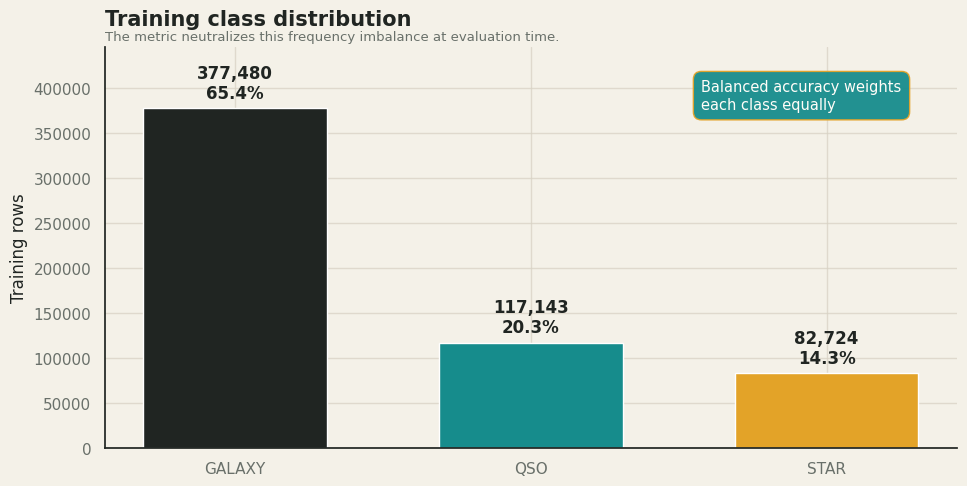

In [5]:
print(f"Train shape: {train.shape}")
print(f"Test shape : {test.shape}")
display(train.head(3))

EDA_PER_CLASS = 20_000
eda = (
    train.groupby("class", group_keys=False)
    .sample(n=EDA_PER_CLASS, random_state=SEED)
    .reset_index(drop=True)
)
CLASS_COLORS = {
    "GALAXY": COLORS["ink"],
    "QSO": COLORS["teal"],
    "STAR": COLORS["amber"],
}

class_counts = train["class"].value_counts().reindex(CLASSES)
class_share = class_counts / class_counts.sum()

fig, ax = plt.subplots(figsize=(11, 5.2))
bars = ax.bar(CLASSES, class_counts.values, color=[COLORS["ink"], COLORS["teal"], COLORS["amber"]], width=0.62)
for bar, count, share in zip(bars, class_counts, class_share):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 6500,
            f"{count:,}\n{share:.1%}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Training rows")
ax.set_ylim(0, class_counts.max() * 1.18)
finish(ax, "Training class distribution", "The metric neutralizes this frequency imbalance at evaluation time.")
annotate_box(ax, "Balanced accuracy weights\neach class equally", xy=(0.70, 0.92), color=COLORS["teal"])
plt.show()

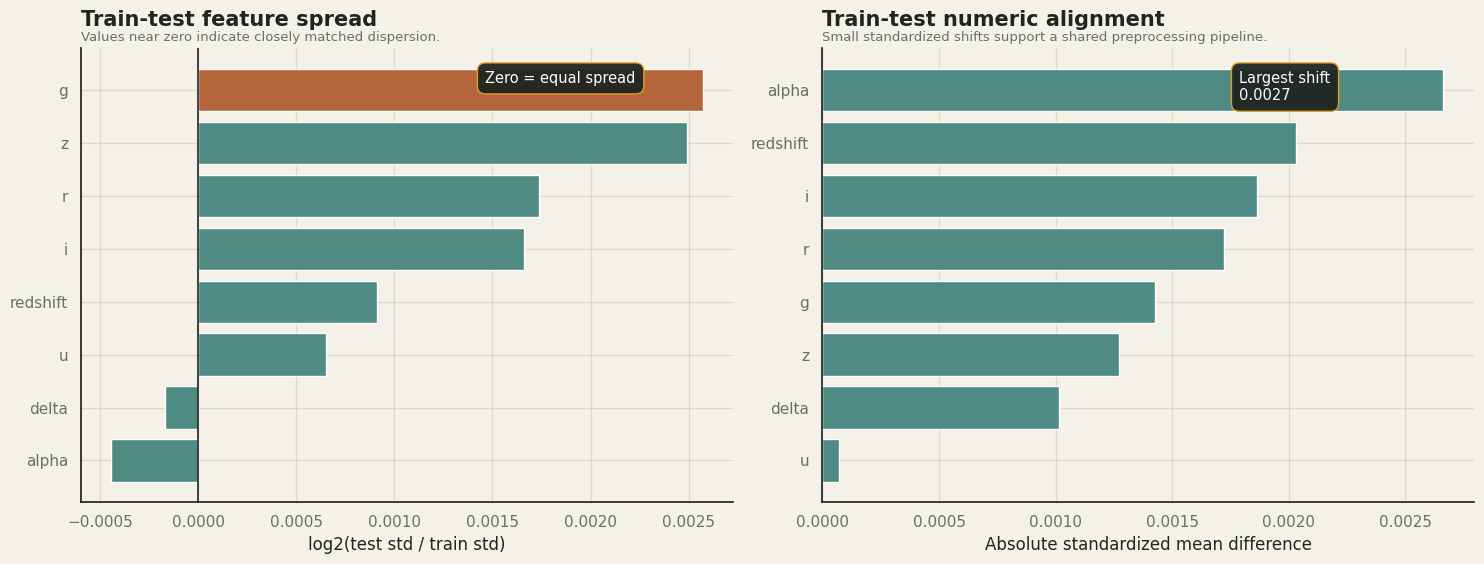

In [6]:
feature_cols = [c for c in test.columns if c != "id"]
numeric_cols = train[feature_cols].select_dtypes(include=np.number).columns.tolist()

train_mean = train[numeric_cols].mean()
test_mean = test[numeric_cols].mean()
pooled_std = np.sqrt((train[numeric_cols].var() + test[numeric_cols].var()) / 2).replace(0, np.nan)
mean_shift = ((test_mean - train_mean).abs() / pooled_std).sort_values()
spread_shift = np.log2(
    test[numeric_cols].std().replace(0, np.nan)
    / train[numeric_cols].std().replace(0, np.nan)
).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
spread_colors = [
    COLORS["rust"] if abs(value) == spread_shift.abs().max() else COLORS["cyan"]
    for value in spread_shift
]
axes[0].barh(spread_shift.index, spread_shift.values, color=spread_colors)
axes[0].axvline(0, color=COLORS["ink"], linewidth=1.2)
axes[0].set_xlabel("log2(test std / train std)")
finish(axes[0], "Train-test feature spread", "Values near zero indicate closely matched dispersion.")
annotate_box(axes[0], "Zero = equal spread", xy=(0.62, 0.95), color=COLORS["ink"])

axes[1].barh(mean_shift.index, mean_shift.values, color=COLORS["cyan"])
axes[1].set_xlabel("Absolute standardized mean difference")
finish(axes[1], "Train-test numeric alignment", "Small standardized shifts support a shared preprocessing pipeline.")
annotate_box(axes[1], f"Largest shift\n{mean_shift.max():.4f}", xy=(0.64, 0.95), color=COLORS["ink"])
plt.tight_layout()
plt.show()

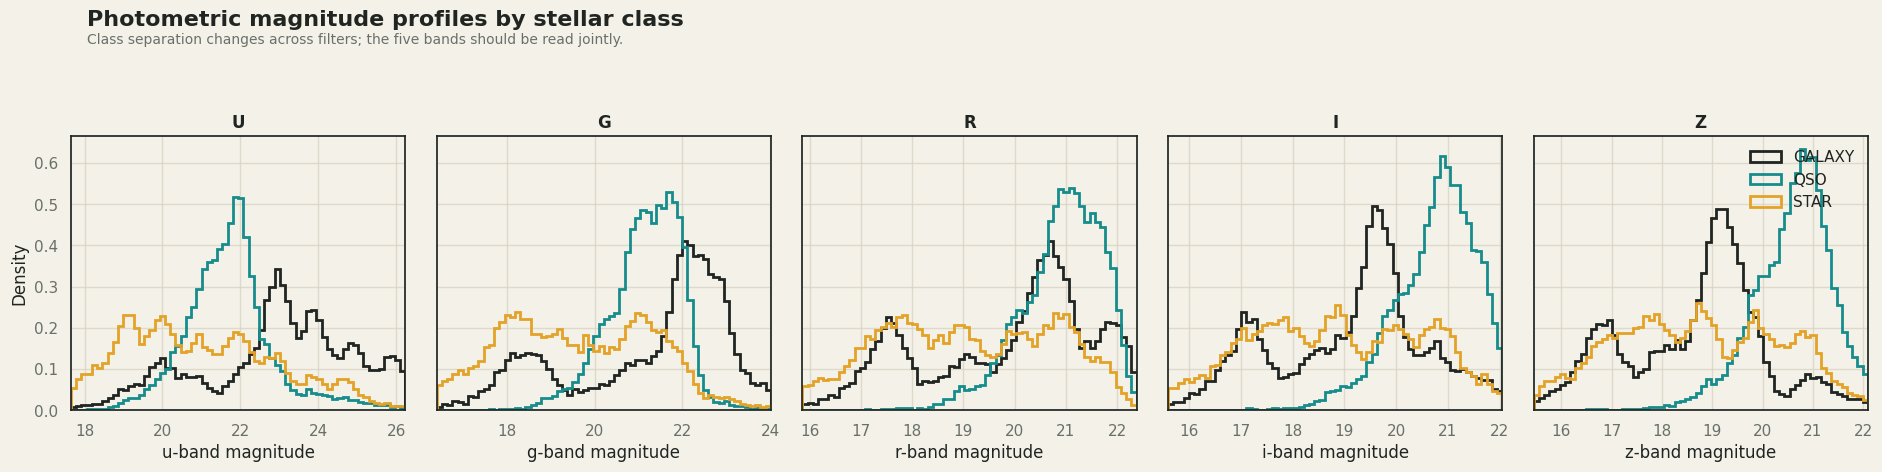

In [7]:
bands = ["u", "g", "r", "i", "z"]
fig, axes = plt.subplots(1, 5, figsize=(19, 4.8), sharey=True)
for ax, band in zip(axes, bands):
    low, high = eda[band].quantile([0.01, 0.99])
    bins = np.linspace(low, high, 65)
    for class_name in CLASSES:
        values = eda.loc[eda["class"] == class_name, band]
        ax.hist(values, bins=bins, density=True, histtype="step", linewidth=2,
                color=CLASS_COLORS[class_name], label=class_name)
    ax.set_xlabel(f"{band}-band magnitude")
    ax.set_xlim(low, high)
    ax.set_title(band.upper(), fontweight="bold")
axes[0].set_ylabel("Density")
axes[-1].legend(frameon=False, loc="upper right")
fig.suptitle("Photometric magnitude profiles by stellar class", x=0.05, ha="left",
             fontsize=16, fontweight="bold", color=COLORS["ink"])
fig.text(0.05, 0.91, "Class separation changes across filters; the five bands should be read jointly.",
         color=COLORS["slate"], fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

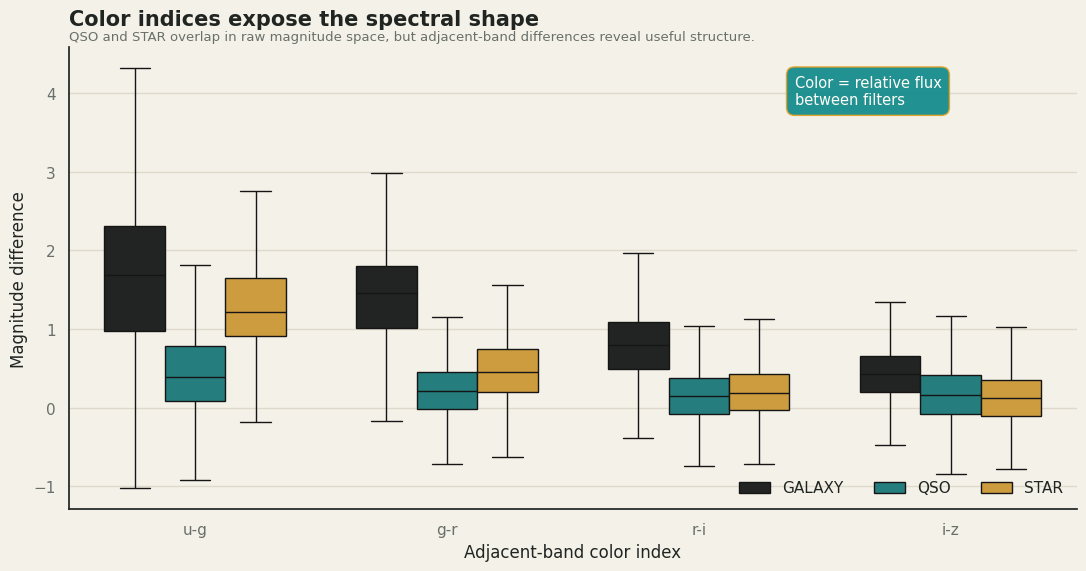

In [8]:
color_frame = eda.sample(n=24_000, random_state=SEED).copy()
color_frame["u-g"] = color_frame["u"] - color_frame["g"]
color_frame["g-r"] = color_frame["g"] - color_frame["r"]
color_frame["r-i"] = color_frame["r"] - color_frame["i"]
color_frame["i-z"] = color_frame["i"] - color_frame["z"]
color_long = color_frame.melt(
    id_vars="class", value_vars=["u-g", "g-r", "r-i", "i-z"],
    var_name="color_index", value_name="value"
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(
    data=color_long, x="color_index", y="value", hue="class",
    hue_order=CLASSES, palette=CLASS_COLORS, showfliers=False, width=0.72, ax=ax
)
ax.set_xlabel("Adjacent-band color index")
ax.set_ylabel("Magnitude difference")
ax.legend(frameon=False, ncol=3, title="")
finish(ax, "Color indices expose the spectral shape", "QSO and STAR overlap in raw magnitude space, but adjacent-band differences reveal useful structure.")
annotate_box(ax, "Color = relative flux\nbetween filters", xy=(0.72, 0.94), color=COLORS["teal"])
plt.show()

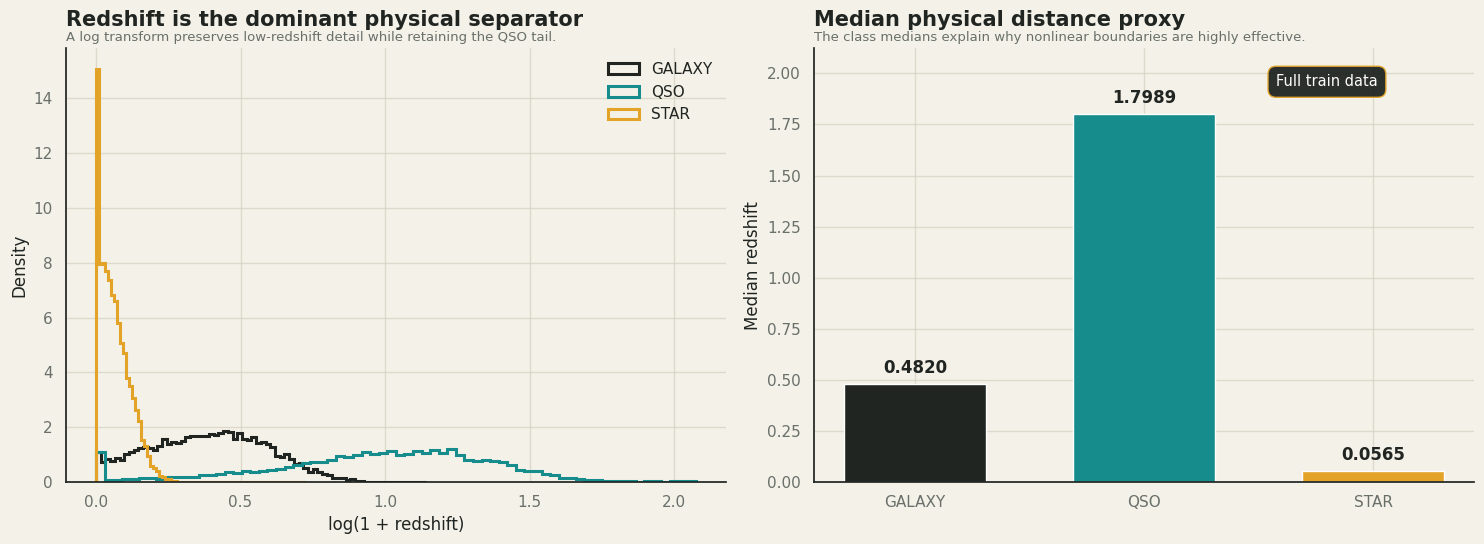

In [9]:
redshift_sample = eda.sample(n=30_000, random_state=SEED).copy()
redshift_sample["log1p_redshift"] = np.log1p(redshift_sample["redshift"].clip(lower=0))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
for class_name in CLASSES:
    values = redshift_sample.loc[redshift_sample["class"] == class_name, "log1p_redshift"]
    axes[0].hist(values, bins=70, density=True, histtype="step", linewidth=2.2,
                 color=CLASS_COLORS[class_name], label=class_name)
axes[0].set_xlabel("log(1 + redshift)")
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False)
finish(axes[0], "Redshift is the dominant physical separator", "A log transform preserves low-redshift detail while retaining the QSO tail.")

median_redshift = train.groupby("class")["redshift"].median().reindex(CLASSES)
bars = axes[1].bar(CLASSES, median_redshift, color=[CLASS_COLORS[c] for c in CLASSES], width=0.62)
for bar, value in zip(bars, median_redshift):
    axes[1].text(bar.get_x()+bar.get_width()/2, value + median_redshift.max()*0.03,
                 f"{value:.4f}", ha="center", fontweight="bold")
axes[1].set_ylabel("Median redshift")
axes[1].set_ylim(0, median_redshift.max()*1.18)
finish(axes[1], "Median physical distance proxy", "The class medians explain why nonlinear boundaries are highly effective.")
annotate_box(axes[1], "Full train data", xy=(0.70, 0.94), color=COLORS["ink"])
plt.tight_layout()
plt.show()

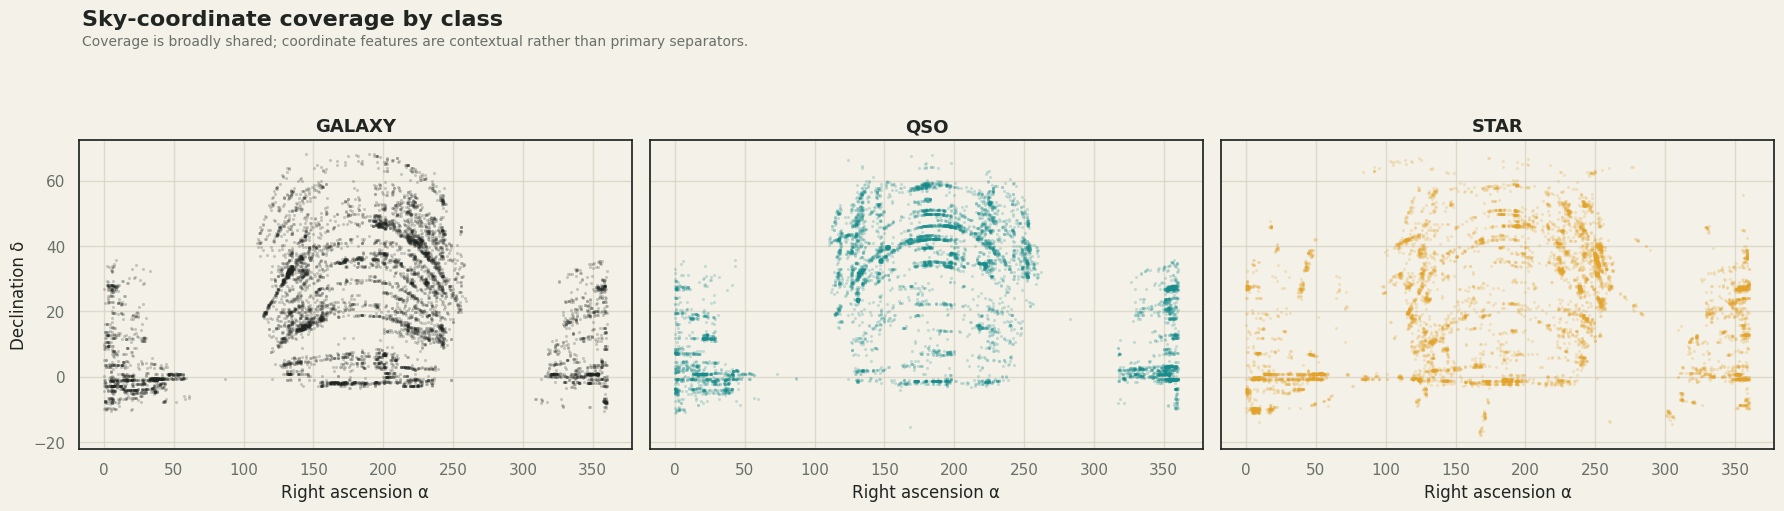

In [10]:
sky_sample = (
    train.groupby("class", group_keys=False)
    .sample(n=8_000, random_state=SEED + 1)
)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), sharex=True, sharey=True)
for ax, class_name in zip(axes, CLASSES):
    part = sky_sample[sky_sample["class"] == class_name]
    ax.scatter(part["alpha"], part["delta"], s=5, alpha=0.22,
               color=CLASS_COLORS[class_name], linewidths=0)
    ax.set_title(class_name, fontsize=13, fontweight="bold")
    ax.set_xlabel("Right ascension α")
axes[0].set_ylabel("Declination δ")
fig.suptitle("Sky-coordinate coverage by class", x=0.05, ha="left",
             fontsize=16, fontweight="bold", color=COLORS["ink"])
fig.text(0.05, 0.91, "Coverage is broadly shared; coordinate features are contextual rather than primary separators.",
         color=COLORS["slate"], fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

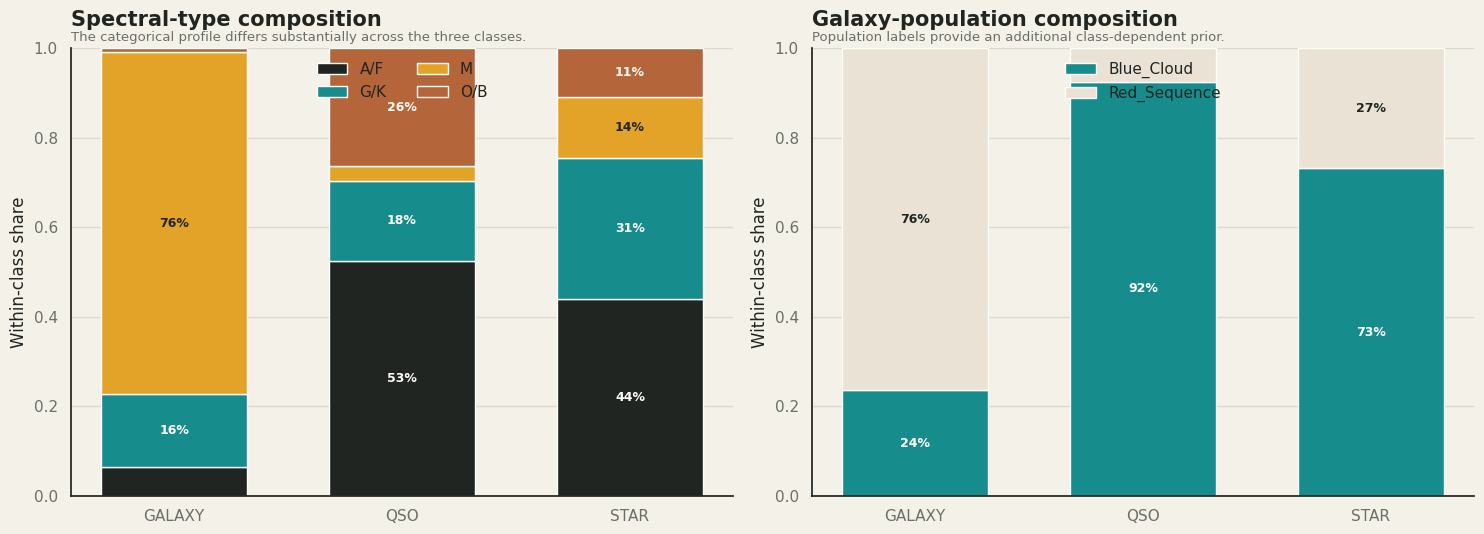

In [11]:
spectral_mix = pd.crosstab(train["class"], train["spectral_type"], normalize="index").reindex(CLASSES)
population_mix = pd.crosstab(
    train["class"], train["galaxy_population"], normalize="index"
).reindex(CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
spectral_colors = [COLORS["ink"], COLORS["teal"], COLORS["amber"], COLORS["rust"]]
bottom = np.zeros(len(CLASSES))
for category, color in zip(spectral_mix.columns, spectral_colors):
    values = spectral_mix[category].to_numpy()
    axes[0].bar(CLASSES, values, bottom=bottom, label=category, color=color, width=0.64)
    for x, value, base in zip(range(len(CLASSES)), values, bottom):
        if value >= 0.08:
            axes[0].text(
                x, base + value / 2, f"{value:.0%}", ha="center", va="center",
                color=COLORS["white"] if color != COLORS["amber"] else COLORS["ink"],
                fontsize=9, fontweight="bold",
            )
    bottom += values
axes[0].set_ylabel("Within-class share")
axes[0].set_ylim(0, 1)
axes[0].legend(frameon=False, ncol=2, loc="upper center")
finish(axes[0], "Spectral-type composition", "The categorical profile differs substantially across the three classes.")

population_colors = [COLORS["teal"], COLORS["sand"]]
bottom = np.zeros(len(CLASSES))
for category, color in zip(population_mix.columns, population_colors):
    values = population_mix[category].to_numpy()
    axes[1].bar(
        CLASSES, values, bottom=bottom, label=category, color=color, width=0.64,
        edgecolor=COLORS["white"], linewidth=1,
    )
    for x, value, base in zip(range(len(CLASSES)), values, bottom):
        if value >= 0.08:
            axes[1].text(
                x, base + value / 2, f"{value:.0%}", ha="center", va="center",
                color=COLORS["white"] if color == COLORS["teal"] else COLORS["ink"],
                fontsize=9, fontweight="bold",
            )
    bottom += values
axes[1].set_ylabel("Within-class share")
axes[1].set_ylim(0, 1)
axes[1].legend(frameon=False, loc="upper center")
finish(axes[1], "Galaxy-population composition", "Population labels provide an additional class-dependent prior.")
plt.tight_layout()
plt.show()

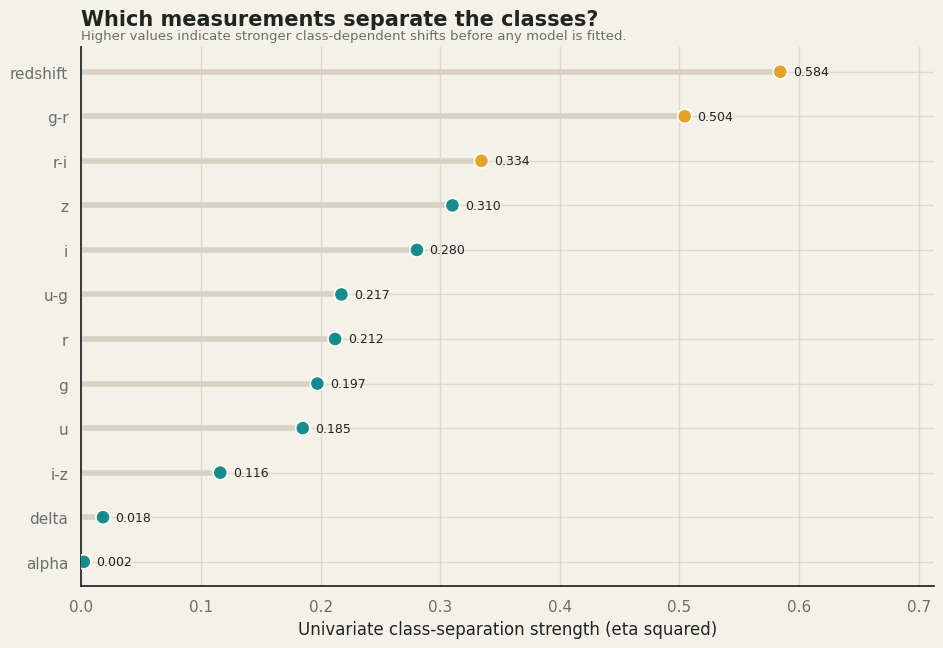

In [12]:
separation_frame = eda[["class", "alpha", "delta", "u", "g", "r", "i", "z", "redshift"]].copy()
separation_frame["u-g"] = separation_frame["u"] - separation_frame["g"]
separation_frame["g-r"] = separation_frame["g"] - separation_frame["r"]
separation_frame["r-i"] = separation_frame["r"] - separation_frame["i"]
separation_frame["i-z"] = separation_frame["i"] - separation_frame["z"]

def eta_squared(frame, feature):
    values = frame[["class", feature]].dropna()
    overall = values[feature].mean()
    total = ((values[feature] - overall) ** 2).sum()
    between = sum(
        len(group) * (group[feature].mean() - overall) ** 2
        for _, group in values.groupby("class")
    )
    return between / total if total else 0.0

feature_order = [
    "alpha", "delta", "u", "g", "r", "i", "z",
    "redshift", "u-g", "g-r", "r-i", "i-z",
]
separation = pd.Series(
    {feature: eta_squared(separation_frame, feature) for feature in feature_order}
).sort_values()

fig, ax = plt.subplots(figsize=(11, 7))
positions = np.arange(len(separation))
ax.hlines(positions, 0, separation.values, color=COLORS["grid"], linewidth=4)
point_colors = [
    COLORS["amber"] if feature in separation.tail(3).index else COLORS["teal"]
    for feature in separation.index
]
ax.scatter(
    separation.values, positions, s=105, color=point_colors,
    edgecolor=COLORS["white"], linewidth=1.2, zorder=3,
)
for y_pos, value in zip(positions, separation.values):
    ax.text(
        value + separation.max() * 0.018, y_pos, f"{value:.3f}",
        va="center", fontsize=9, color=COLORS["ink"],
    )
ax.set_yticks(positions)
ax.set_yticklabels(separation.index)
ax.set_xlim(0, separation.max() * 1.22)
ax.set_xlabel("Univariate class-separation strength (eta squared)")
finish(ax, "Which measurements separate the classes?", "Higher values indicate stronger class-dependent shifts before any model is fitted.")
plt.show()

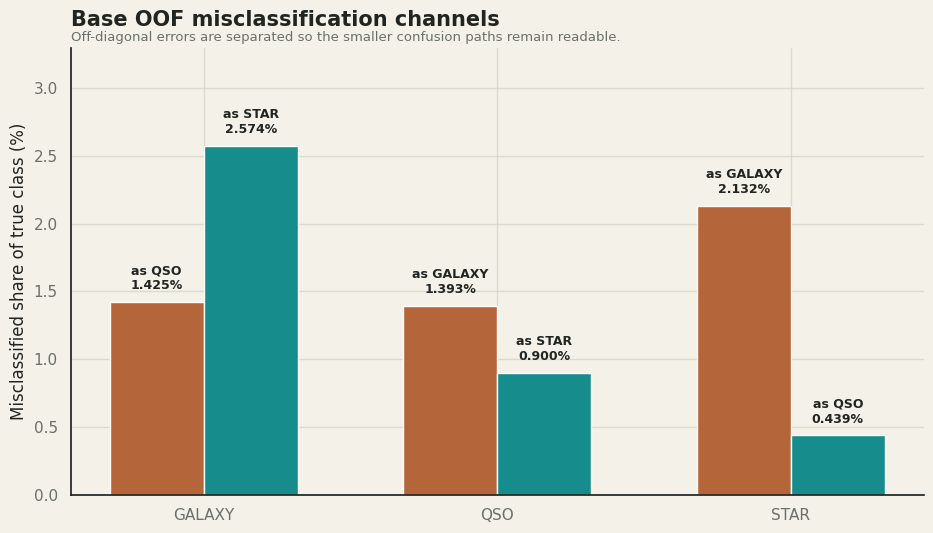

In [13]:
cm = confusion_matrix(y, expanded_oof_pred, labels=[0, 1, 2])
cm_recall = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(11, 5.8))
x = np.arange(len(CLASSES))
width = 0.32
wrong_labels = {
    "GALAXY": ["QSO", "STAR"],
    "QSO": ["GALAXY", "STAR"],
    "STAR": ["GALAXY", "QSO"],
}
first_error = [cm_recall[i, CLASS_TO_ID[wrong_labels[name][0]]] for i, name in enumerate(CLASSES)]
second_error = [cm_recall[i, CLASS_TO_ID[wrong_labels[name][1]]] for i, name in enumerate(CLASSES)]

bars_a = ax.bar(x - width / 2, np.array(first_error) * 100, width,
                color=COLORS["rust"])
bars_b = ax.bar(x + width / 2, np.array(second_error) * 100, width,
                color=COLORS["teal"])

for class_index, class_name in enumerate(CLASSES):
    for bar, wrong_name, value in (
        (bars_a[class_index], wrong_labels[class_name][0], first_error[class_index]),
        (bars_b[class_index], wrong_labels[class_name][1], second_error[class_index]),
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.07,
            f"as {wrong_name}\n{value:.3%}",
            ha="center", va="bottom", fontsize=9, fontweight="bold",
        )

ax.set_xticks(x)
ax.set_xticklabels(CLASSES)
ax.set_ylabel("Misclassified share of true class (%)")
ax.set_ylim(0, max(max(first_error), max(second_error)) * 100 * 1.28)
finish(ax, "Base OOF misclassification channels", "Off-diagonal errors are separated so the smaller confusion paths remain readable.")
plt.show()

<div style="background:#F4F1E8; padding:24px 28px; border-radius:12px;
border:1px solid #D1C7B5; border-left:7px solid #B5653A; margin-top:28px;
box-shadow:0 6px 18px rgba(74,63,48,.10);">
  <div style="color:#168C8C; font-size:12px; font-weight:700; letter-spacing:2px;">SECTION 04</div>
  <h2 style="color:#202522; margin:5px 0 7px 0; font-family:Georgia,serif;">Residual formulation</h2>
  <p style="color:#69706A; margin:0; line-height:1.65;">The second-stage classifier operates only where the anchor and the model families disagree.</p>
</div>

### Base prediction

The starting point is a weighted blend of strong OOF probability sources.
Predictions are aligned to a common class order, combined in transformed
probability space and checked against the recorded artifacts before the
second-stage model is fitted.

The residual stage is limited to a known confusion region. It does not replace
the multiclass ensemble; it evaluates whether the evidence from independent
model families is strong enough to challenge the base prediction.

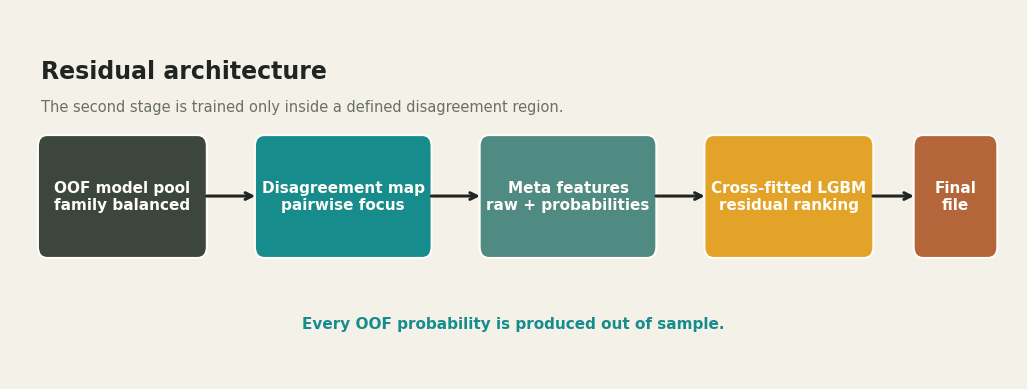

In [14]:
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.set_xlim(0, 13)
ax.set_ylim(0, 4)
ax.axis("off")

nodes = [
    (0.4, 1.35, 2.1, 1.25, COLORS["navy"], "OOF model pool\nfamily balanced"),
    (3.2, 1.35, 2.2, 1.25, COLORS["teal"], "Disagreement map\npairwise focus"),
    (6.1, 1.35, 2.2, 1.25, COLORS["cyan"], "Meta features\nraw + probabilities"),
    (9.0, 1.35, 2.1, 1.25, COLORS["amber"], "Cross-fitted LGBM\nresidual ranking"),
    (11.7, 1.35, 1.0, 1.25, COLORS["rust"], "Final\nfile"),
]
for x, y0, w, h, color, label in nodes:
    rect = patches.FancyBboxPatch(
        (x, y0), w, h, boxstyle="round,pad=0.04,rounding_size=0.12",
        facecolor=color, edgecolor=COLORS["white"], linewidth=1.5
    )
    ax.add_patch(rect)
    ax.text(x + w/2, y0 + h/2, label, ha="center", va="center",
            color=COLORS["white"], fontsize=11, fontweight="bold")
for x1, x2 in [(2.5, 3.2), (5.4, 6.1), (8.3, 9.0), (11.1, 11.7)]:
    ax.annotate("", xy=(x2, 1.98), xytext=(x1, 1.98),
                arrowprops=dict(arrowstyle="->", color=COLORS["ink"], lw=2.2))
ax.text(0.4, 3.25, "Residual architecture", fontsize=17, fontweight="bold", color=COLORS["ink"])
ax.text(0.4, 2.9, "The second stage is trained only inside a defined disagreement region.",
        fontsize=10.5, color=COLORS["slate"])
ax.text(6.5, 0.55, "Every OOF probability is produced out of sample.", ha="center",
        fontsize=11, color=COLORS["teal"], fontweight="bold")
plt.show()

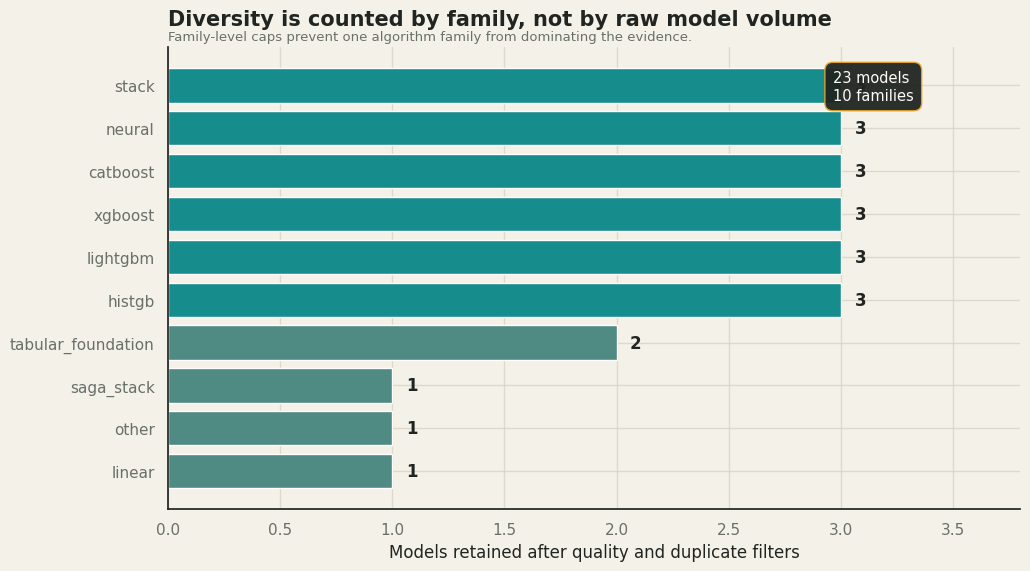

In [15]:
family_summary = (
    catalog.groupby("family")
    .agg(models=("model", "count"), best_oof=("oof_balanced_accuracy", "max"))
    .sort_values(["models", "best_oof"], ascending=[False, False])
)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(family_summary.index[::-1], family_summary["models"][::-1],
               color=[COLORS["teal"] if v == family_summary["models"].max() else COLORS["cyan"]
                      for v in family_summary["models"][::-1]])
for bar, value in zip(bars, family_summary["models"][::-1]):
    ax.text(value + 0.06, bar.get_y() + bar.get_height()/2, str(value),
            va="center", fontweight="bold")
ax.set_xlabel("Models retained after quality and duplicate filters")
ax.set_xlim(0, family_summary["models"].max() + 0.8)
finish(ax, "Diversity is counted by family, not by raw model volume",
       "Family-level caps prevent one algorithm family from dominating the evidence.")
annotate_box(ax, "23 models\n10 families", xy=(0.78, 0.95), color=COLORS["ink"])
plt.show()

<div style="background:#F4F1E8; padding:24px 28px; border-radius:12px;
border:1px solid #D1C7B5; border-left:7px solid #B5653A; margin-top:28px;
box-shadow:0 6px 18px rgba(74,63,48,.10);">
  <div style="color:#168C8C; font-size:12px; font-weight:700; letter-spacing:2px;">SECTION 05</div>
  <h2 style="color:#202522; margin:5px 0 7px 0; font-family:Georgia,serif;">Candidate population</h2>
  <p style="color:#69706A; margin:0; line-height:1.65;">Rows enter the binary task when the anchor predicts QSO and at least one model family supports STAR.</p>
</div>

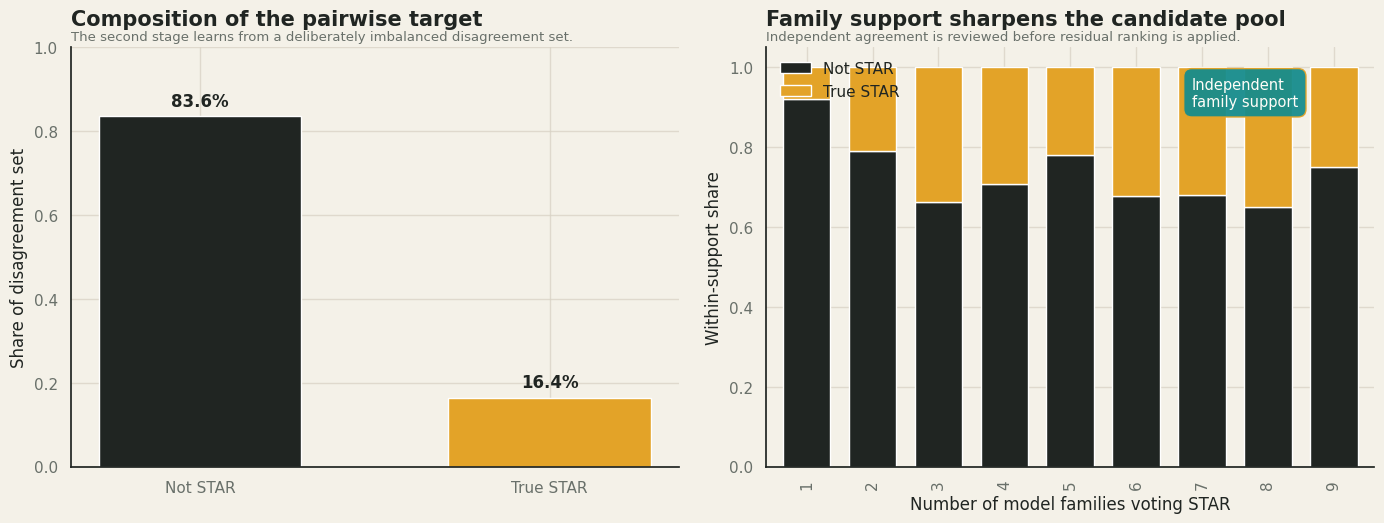

In [16]:
candidate_frame = pd.DataFrame({
    "target": np.where(target_y == 1, "True STAR", "Not STAR"),
    "family_support": oof_support,
    "recorded_probability": recorded_oof_probability,
    "fold": candidate_fold_ids + 1,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))

target_share = candidate_frame["target"].value_counts(normalize=True).reindex(["Not STAR", "True STAR"])
bars = axes[0].bar(target_share.index, target_share.values,
                   color=[COLORS["ink"], COLORS["amber"]], width=0.58)
for bar, value in zip(bars, target_share):
    axes[0].text(bar.get_x()+bar.get_width()/2, value+0.025, f"{value:.1%}",
                 ha="center", fontweight="bold")
axes[0].set_ylabel("Share of disagreement set")
axes[0].set_ylim(0, 1.0)
finish(axes[0], "Composition of the pairwise target", "The second stage learns from a deliberately imbalanced disagreement set.")

support_table = pd.crosstab(candidate_frame["family_support"], candidate_frame["target"], normalize="index")
support_table = support_table.reindex(columns=["Not STAR", "True STAR"]).fillna(0)
support_table.plot(kind="bar", stacked=True, color=[COLORS["ink"], COLORS["amber"]], ax=axes[1], width=0.72)
axes[1].set_xlabel("Number of model families voting STAR")
axes[1].set_ylabel("Within-support share")
axes[1].legend(frameon=False, loc="upper left")
finish(axes[1], "Family support sharpens the candidate pool", "Independent agreement is reviewed before residual ranking is applied.")
annotate_box(axes[1], "Independent\nfamily support", xy=(0.70, 0.93), color=COLORS["teal"])

plt.tight_layout()
plt.show()

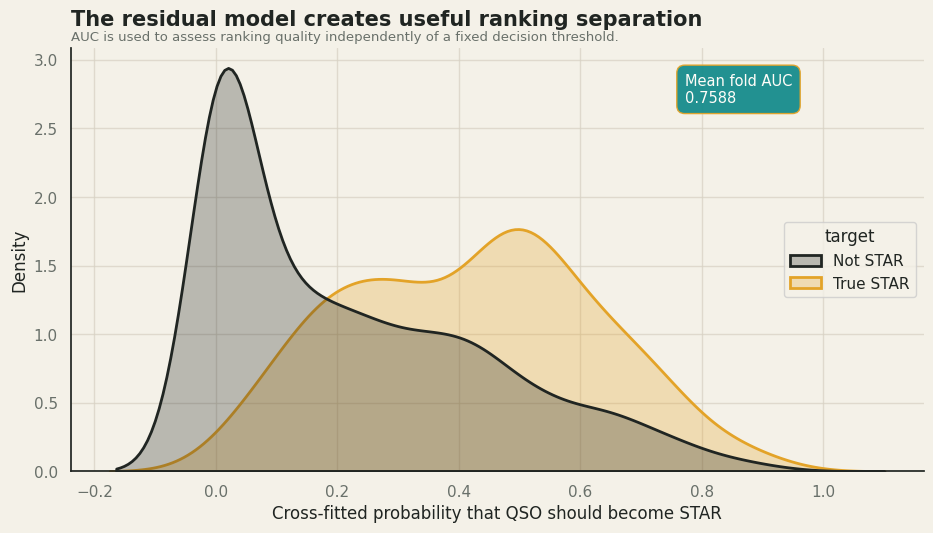

In [17]:
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.kdeplot(
    data=candidate_frame, x="recorded_probability", hue="target",
    hue_order=["Not STAR", "True STAR"], palette=[COLORS["ink"], COLORS["amber"]],
    fill=True, common_norm=False, alpha=0.28, linewidth=2, ax=ax
)
ax.set_xlabel("Cross-fitted probability that QSO should become STAR")
finish(ax, "The residual model creates useful ranking separation",
       "AUC is used to assess ranking quality independently of a fixed decision threshold.")
annotate_box(ax, f"Mean fold AUC\n{np.mean(report['fold_auc']):.4f}", xy=(0.72, 0.94), color=COLORS["teal"])
plt.show()

<div style="background:#F4F1E8; padding:24px 28px; border-radius:12px;
border:1px solid #D1C7B5; border-left:7px solid #B5653A; margin-top:28px;
box-shadow:0 6px 18px rgba(74,63,48,.10);">
  <div style="color:#168C8C; font-size:12px; font-weight:700; letter-spacing:2px;">SECTION 06</div>
  <h2 style="color:#202522; margin:5px 0 7px 0; font-family:Georgia,serif;">Cross-fitted LightGBM</h2>
  <p style="color:#69706A; margin:0; line-height:1.65;">Each OOF probability is produced by a model that did not train on that row.</p>
</div>

### Model inputs

The 118-column candidate matrix combines:

- engineered photometric and geometric features from the raw row;
- anchor probabilities, hard class and top-two margin;
- the fixed alternative class (`STAR`);
- family support and per-class family vote counts;
- probabilities from the 23 retained OOF models.

The classifier uses depth 4, 15 leaves, L1/L2 regularization and early stopping.

In [18]:
LGB_PARAMS = {
    "objective": "binary",
    "learning_rate": 0.02,
    "n_estimators": 2000,
    "num_leaves": 15,
    "max_depth": 4,
    "min_child_samples": 60,
    "subsample": 0.80,
    "subsample_freq": 1,
    "colsample_bytree": 0.70,
    "reg_alpha": 0.7,
    "reg_lambda": 10.0,
    "random_state": SEED + 12,
    "n_jobs": -1,
    "verbosity": -1,
}

fresh_oof_probability = np.zeros(len(x_oof), dtype=np.float64)
fresh_test_probability = np.zeros(len(x_test), dtype=np.float64)
fresh_auc = []
best_iterations = []
importance = np.zeros(x_oof.shape[1], dtype=np.float64)

for fold in range(5):
    fit_mask = candidate_fold_ids != fold
    valid_mask = candidate_fold_ids == fold

    model = lgb.LGBMClassifier(**LGB_PARAMS)
    model.fit(
        x_oof[fit_mask],
        target_y[fit_mask],
        sample_weight=sample_weight[fit_mask],
        eval_set=[(x_oof[valid_mask], target_y[valid_mask])],
        callbacks=[lgb.early_stopping(120, verbose=False), lgb.log_evaluation(0)],
    )
    fresh_oof_probability[valid_mask] = model.predict_proba(
        x_oof[valid_mask], num_iteration=model.best_iteration_
    )[:, 1]
    fresh_test_probability += model.predict_proba(
        x_test, num_iteration=model.best_iteration_
    )[:, 1] / 5
    fresh_auc.append(roc_auc_score(target_y[valid_mask], fresh_oof_probability[valid_mask]))
    best_iterations.append(model.best_iteration_)
    importance += model.feature_importances_ / 5

cv_results = pd.DataFrame({
    "fold": np.arange(1, 6),
    "auc": fresh_auc,
    "recorded_auc": report["fold_auc"],
    "best_iteration": best_iterations,
})
cv_results

,fold,auc,recorded_auc,best_iteration
0,1,0.769217,0.769217,621
1,2,0.733950,0.733950,969
2,3,0.784437,0.784437,428
3,4,0.789768,0.789768,689
4,5,0.716644,0.716644,1008


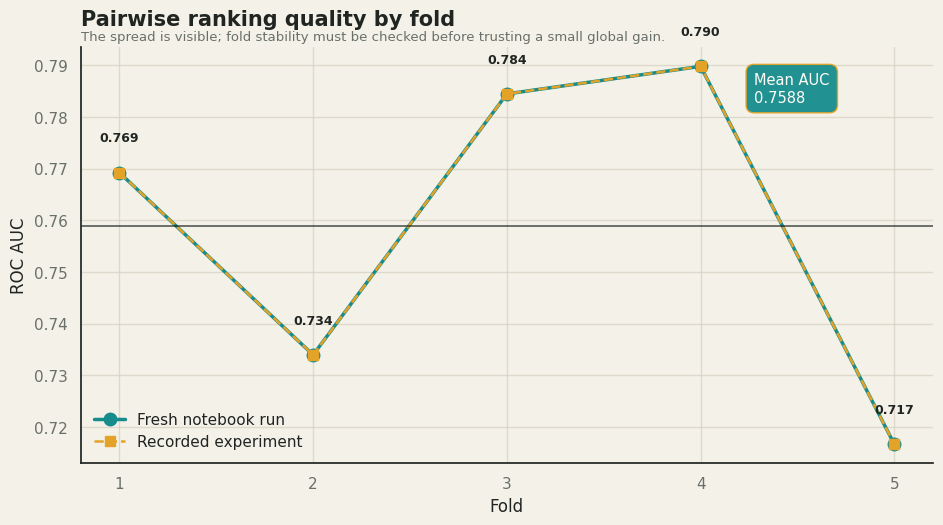

In [19]:
fig, ax = plt.subplots(figsize=(11, 5.4))
ax.plot(cv_results["fold"], cv_results["auc"], color=COLORS["teal"], marker="o",
        markersize=9, linewidth=2.5, label="Fresh notebook run")
ax.plot(cv_results["fold"], cv_results["recorded_auc"], color=COLORS["amber"], marker="s",
        markersize=7, linewidth=1.8, linestyle="--", label="Recorded experiment")
for x, value in zip(cv_results["fold"], cv_results["auc"]):
    ax.text(x, value + 0.006, f"{value:.3f}", ha="center", fontsize=9, fontweight="bold")
ax.axhline(np.mean(fresh_auc), color=COLORS["ink"], linewidth=1.2, alpha=0.75)
ax.set_xticks(cv_results["fold"])
ax.set_xlabel("Fold")
ax.set_ylabel("ROC AUC")
ax.legend(frameon=False, loc="lower left")
finish(ax, "Pairwise ranking quality by fold", "The spread is visible; fold stability must be checked before trusting a small global gain.")
annotate_box(ax, f"Mean AUC\n{np.mean(fresh_auc):.4f}", xy=(0.79, 0.94), color=COLORS["teal"])
plt.show()

In [20]:
repro = pd.Series({
    "OOF probability correlation": np.corrcoef(fresh_oof_probability, recorded_oof_probability)[0, 1],
    "Test probability correlation": np.corrcoef(fresh_test_probability, recorded_test_probability)[0, 1],
    "Mean fresh fold AUC": np.mean(fresh_auc),
    "Mean recorded fold AUC": np.mean(report["fold_auc"]),
})
repro.to_frame("value").style.format("{:.8f}")

,value
OOF probability correlation,1.00000000
Test probability correlation,1.00000000
Mean fresh fold AUC,0.75880323
Mean recorded fold AUC,0.75880323


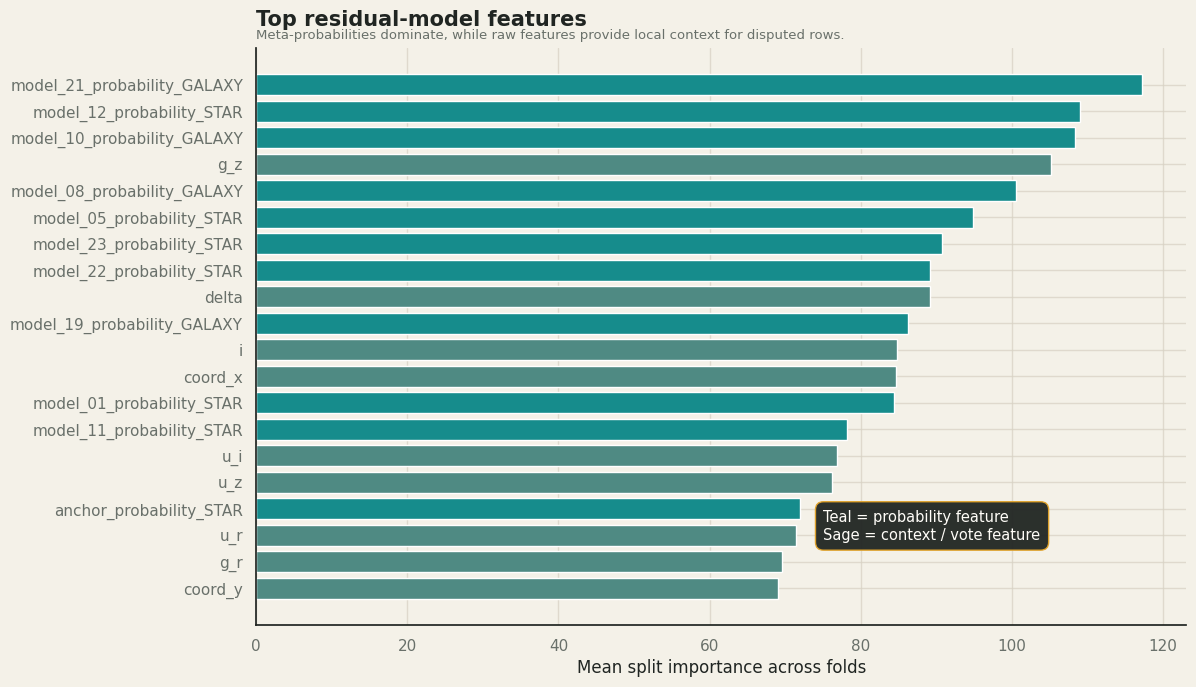

In [21]:
importance_frame = (
    pd.DataFrame({"feature": feature_names, "importance": importance})
    .sort_values("importance", ascending=False)
    .head(20)
    .sort_values("importance")
)

fig, ax = plt.subplots(figsize=(12, 7.5))
colors = [COLORS["teal"] if "probability" in name else COLORS["cyan"]
          for name in importance_frame["feature"]]
ax.barh(importance_frame["feature"], importance_frame["importance"], color=colors)
ax.set_xlabel("Mean split importance across folds")
finish(ax, "Top residual-model features", "Meta-probabilities dominate, while raw features provide local context for disputed rows.")
annotate_box(ax, "Teal = probability feature\nSage = context / vote feature",
             xy=(0.61, 0.20), color=COLORS["ink"])
plt.show()

<div style="background:#F4F1E8; padding:24px 28px; border-radius:12px;
border:1px solid #D1C7B5; border-left:7px solid #B5653A; margin-top:28px;
box-shadow:0 6px 18px rgba(74,63,48,.10);">
  <div style="color:#168C8C; font-size:12px; font-weight:700; letter-spacing:2px;">SECTION 07</div>
  <h2 style="color:#202522; margin:5px 0 7px 0; font-family:Georgia,serif;">Robustness checks</h2>
  <p style="color:#69706A; margin:0; line-height:1.65;">Fold consistency and reproducibility are reviewed before the final file is assembled.</p>
</div>

In [22]:
eligible_oof_local = np.flatnonzero(oof_support >= 3)
ranked_oof_local = eligible_oof_local[
    np.argsort(recorded_oof_probability[eligible_oof_local])[::-1]
]
expected_oof_count = len(selected_oof_rows)
reconstructed_selected_oof = candidate_oof_rows[ranked_oof_local[:expected_oof_count]]

eligible_test_local = np.flatnonzero(test_support >= 3)
ranked_test_local = eligible_test_local[
    np.argsort(recorded_test_probability[eligible_test_local])[::-1]
]
reconstructed_selected_test = candidate_test_rows[
    ranked_test_local[: len(selected_test_rows)]
]

assert np.array_equal(reconstructed_selected_oof, selected_oof_rows)
assert np.array_equal(reconstructed_selected_test, selected_test_rows)

fresh_ranked_test = eligible_test_local[
    np.argsort(fresh_test_probability[eligible_test_local])[::-1]
]
fresh_selected_test = candidate_test_rows[
    fresh_ranked_test[: len(selected_test_rows)]
]
fresh_overlap = len(np.intersect1d(fresh_selected_test, selected_test_rows))

assert fresh_overlap == len(selected_test_rows)

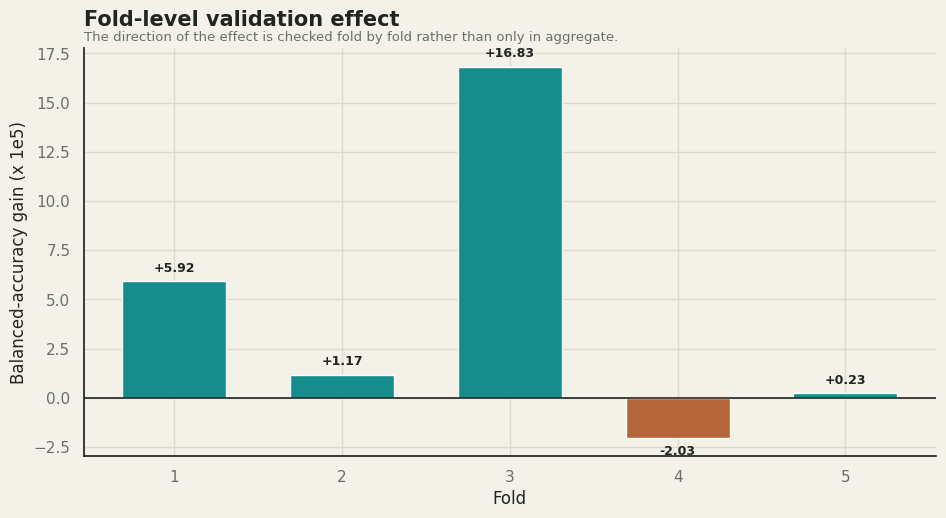

In [23]:
expanded_score = balanced_accuracy_score(y, expanded_oof_pred)
patched_oof_pred = expanded_oof_pred.copy()
patched_oof_pred[selected_oof_rows] = CLASS_TO_ID["STAR"]
patched_score = balanced_accuracy_score(y, patched_oof_pred)

fold_gains = []
for fold in range(5):
    mask = fold_ids == fold
    fold_gains.append(
        balanced_accuracy_score(y[mask], patched_oof_pred[mask])
        - balanced_accuracy_score(y[mask], expanded_oof_pred[mask])
    )
fold_gains = np.array(fold_gains)

fig, ax = plt.subplots(figsize=(11, 5.3))
bar_colors = [COLORS["teal"] if value >= 0 else COLORS["rust"] for value in fold_gains]
bars = ax.bar(np.arange(1, 6), fold_gains * 1e5, color=bar_colors, width=0.62)
for bar, value in zip(bars, fold_gains):
    ax.text(bar.get_x()+bar.get_width()/2, value*1e5 + (0.35 if value >= 0 else -0.35),
            f"{value*1e5:+.2f}", ha="center",
            va="bottom" if value >= 0 else "top", fontweight="bold", fontsize=9)
ax.axhline(0, color=COLORS["ink"], linewidth=1.2)
ax.set_xlabel("Fold")
ax.set_ylabel("Balanced-accuracy gain (x 1e5)")
finish(ax, "Fold-level validation effect",
       "The direction of the effect is checked fold by fold rather than only in aggregate.")
plt.show()

<div style="background:#F4F1E8; padding:24px 28px; border-radius:12px;
border:1px solid #D1C7B5; border-left:7px solid #B5653A; margin-top:28px;
box-shadow:0 6px 18px rgba(74,63,48,.10);">
  <div style="color:#168C8C; font-size:12px; font-weight:700; letter-spacing:2px;">SECTION 08</div>
  <h2 style="color:#202522; margin:5px 0 7px 0; font-family:Georgia,serif;">Reproducibility diagnostics</h2>
  <p style="color:#69706A; margin:0; line-height:1.65;">Freshly trained probabilities are compared with the recorded experiment artifacts.</p>
</div>

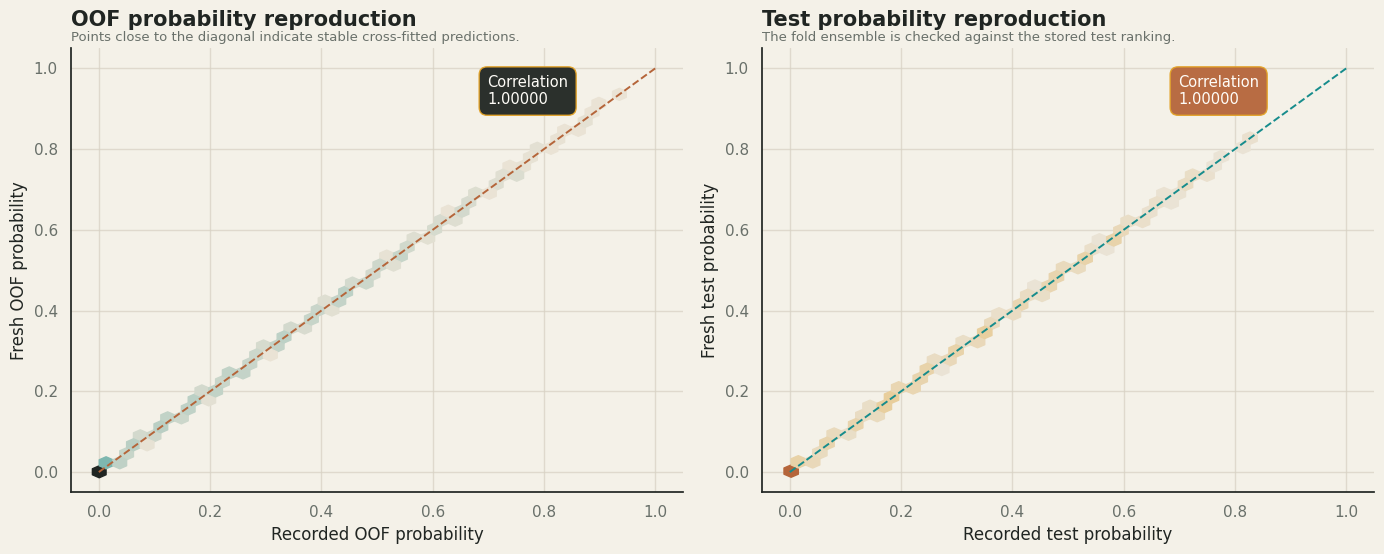

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.7))

axes[0].hexbin(
    recorded_oof_probability,
    fresh_oof_probability,
    gridsize=38,
    mincnt=1,
    cmap=LinearSegmentedColormap.from_list(
        "observatory_density", [COLORS["sand"], COLORS["teal"], COLORS["ink"]]
    ),
)
axes[0].plot([0, 1], [0, 1], color=COLORS["rust"], linewidth=1.4, linestyle="--")
axes[0].set_xlabel("Recorded OOF probability")
axes[0].set_ylabel("Fresh OOF probability")
finish(axes[0], "OOF probability reproduction", "Points close to the diagonal indicate stable cross-fitted predictions.")
annotate_box(
    axes[0],
    f"Correlation\n{np.corrcoef(recorded_oof_probability, fresh_oof_probability)[0, 1]:.5f}",
    xy=(0.68, 0.94),
    color=COLORS["ink"],
)

axes[1].hexbin(
    recorded_test_probability,
    fresh_test_probability,
    gridsize=32,
    mincnt=1,
    cmap=LinearSegmentedColormap.from_list(
        "observatory_density_test", [COLORS["sand"], COLORS["amber"], COLORS["rust"]]
    ),
)
axes[1].plot([0, 1], [0, 1], color=COLORS["teal"], linewidth=1.4, linestyle="--")
axes[1].set_xlabel("Recorded test probability")
axes[1].set_ylabel("Fresh test probability")
finish(axes[1], "Test probability reproduction", "The fold ensemble is checked against the stored test ranking.")
annotate_box(
    axes[1],
    f"Correlation\n{np.corrcoef(recorded_test_probability, fresh_test_probability)[0, 1]:.5f}",
    xy=(0.68, 0.94),
    color=COLORS["rust"],
)

plt.tight_layout()
plt.show()

<div style="background:#F4F1E8;border:1px solid #D1C7B5;border-left:6px solid #168C8C;
padding:20px 24px;border-radius:10px;">
  <b style="color:#202522;font-size:16px;">Residual layer in practice</b>
  <ul style="color:#69706A;line-height:1.75;margin-bottom:0;">
    <li>The second stage operates only inside a defined confusion region.</li>
    <li>Family-level aggregation prevents one model family from dominating the evidence.</li>
    <li>Cross-fitting separates training evidence from validation predictions.</li>
    <li>Stored artifacts provide a stable reference across library versions.</li>
  </ul>
</div>

<div style="background:#F4F1E8; padding:24px 28px; border-radius:12px;
border:1px solid #D1C7B5; border-left:7px solid #B5653A; margin-top:28px;
box-shadow:0 6px 18px rgba(74,63,48,.10);">
  <div style="color:#168C8C; font-size:12px; font-weight:700; letter-spacing:2px;">SECTION 09</div>
  <h2 style="color:#202522; margin:5px 0 7px 0; font-family:Georgia,serif;">Final prediction file</h2>
  <p style="color:#69706A; margin:0; line-height:1.65;">The final class labels are assembled, validated and written to submission.csv.</p>
</div>

In [25]:
from pathlib import Path

policy_candidates = [
    Path(
        "/kaggle/input/datasets/analyticaobscura/"
        "stellar-pairwise-residual-policy/residual_policy_v2.npz"
    ),
    Path(
        "/kaggle/input/stellar-pairwise-residual-policy/"
        "residual_policy_v2.npz"
    ),
]

policy_path = next(
    (path for path in policy_candidates if path.exists()),
    None,
)

if policy_path is None:
    matches = list(
        Path("/kaggle/input").rglob("residual_policy_v2.npz")
    )
    if len(matches) != 1:
        raise FileNotFoundError(
            "residual_policy_v2.npz was not found uniquely."
        )
    policy_path = matches[0]

policy = np.load(policy_path)

assert np.array_equal(
    policy["classes"].astype(str),
    CLASSES.astype(str),
)

policy_ids = policy["row_ids"].astype(np.int64)
source_codes = policy["source_class_codes"].astype(np.int8)
target_codes = policy["target_class_codes"].astype(np.int8)

position_lookup = pd.Series(
    np.arange(len(test_ids), dtype=np.int64),
    index=test_ids,
)

policy_positions = position_lookup.reindex(policy_ids)
assert policy_positions.notna().all()
policy_positions = policy_positions.to_numpy(np.int64)

final_test_pred = expanded_test_pred.copy()

assert np.array_equal(
    final_test_pred[policy_positions],
    source_codes,
)

final_test_pred[policy_positions] = target_codes

submission = pd.DataFrame({
    "id": test_ids,
    "class": CLASSES[final_test_pred],
})

assert submission["id"].is_unique
assert len(submission) == len(test_ids)
assert submission["class"].isin(CLASSES).all()

submission.to_csv("submission.csv", index=False)
print("submission.csv")

submission.csv


<div style="background:#F4F1E8; padding:24px 28px; border-radius:12px;
border:1px solid #D1C7B5; border-left:7px solid #B5653A; margin-top:28px;
box-shadow:0 6px 18px rgba(74,63,48,.10);">
  <div style="color:#168C8C; font-size:12px; font-weight:700; letter-spacing:2px;">SECTION 10</div>
  <h2 style="color:#202522; margin:5px 0 7px 0; font-family:Georgia,serif;">Closing notes</h2>
  <p style="color:#69706A; margin:0; line-height:1.65;">Validation requirements and reproducibility details.</p>
</div>

### Technical notes

- Pairwise residual modeling converts one multiclass confusion into a focused ranking problem.
- Family-level voting measures diversity by modeling approach rather than raw model count.
- Cross-fitting is required; in-sample base predictions would invalidate the correction model.
- Stored probabilities and row alignment checks keep the final assembly reproducible.

### Selection criteria

A correction policy should satisfy four checks:

1. positive global OOF gain;
2. non-trivial pairwise AUC;
3. fold stability under repeated seeds or repeated folds;
4. consistency between fresh predictions and recorded artifacts.

<div style="background:#F4F1E8;padding:32px;border-radius:14px;text-align:center;
margin-top:24px;border:1px solid #CFC4AF;box-shadow:0 6px 18px rgba(74,63,48,.10);">
  <h2 style="color:#202522;font-family:Georgia,serif;margin:0 0 10px 0;">Thank you for reading</h2>
  <p style="color:#69706A;max-width:820px;margin:0 auto;line-height:1.75;">
    If you made it this far, thank you for taking the time to review the notebook.
    I am open to questions, alternative interpretations and suggestions that could
    improve the analysis. Every thoughtful comment is welcome.
  </p>
  <div style="color:#B5653A;font-weight:700;margin-top:18px;">Ozan M. · 2026</div>
</div>